In [1]:
# how to uncover truths that don't matter - first section. 

In [2]:
# loading libraries already for later use
import gc
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import pandas as pd
import geopandas as gpd

import geodatasets
from shapely.geometry import Point, box

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans, DBSCAN

import coriolis_functions

In [3]:
# loading dataframe with not cancelled flights
fdf = pd.read_csv("data/coriolis_flights_3m.csv", sep=";").astype(
    {
        "FL_DATE": "datetime64[ns]", 
        "AIRLINE": "category", 
        "AIRLINE_DOT": "category", 
        "AIRLINE_CODE": "category", 
        "ORIGIN": "category", 
        "ORIGIN_CITY": "category", 
        "DEST": "category",
        "DEST_CITY": "category", 
        "CANCELLED": "bool",
        "CANCELLATION_CODE": "category", 
        "DIVERTED": "bool",
    }
)

nrows_atstart = len(fdf)

In [4]:
ldf = pd.read_csv("data/airports.csv").astype(
    {
        "IATA": "category",
        "AIRPORT": "category",
        "CITY": "category",
        "STATE": "category",
        "COUNTRY": "category",
    }
)

In [5]:
# checking unique values in both datasets
fdf_airports = set(fdf["ORIGIN"].unique()).union(set(fdf["DEST"].unique()))
ldf_airports = set(ldf["IATA"].unique())  

# finding missing airport codes in ldf
missing_airports = fdf_airports.difference(ldf_airports)

# dropping rows where "ORIGIN" or "DEST" are in missing_airports
fdf = fdf[~fdf["ORIGIN"].isin(missing_airports) & ~fdf["DEST"].isin(missing_airports)]

# merging fdf with ldf to add geographical data for ORIGIN and DEST
fdf = pd.merge(fdf, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="ORIGIN", right_on="IATA", how="left")

fdf = pd.merge(fdf, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="DEST", right_on="IATA", how="left", suffixes=("_ORIGIN", "_DEST"))

# dropping original origin and destination columns
fdf = fdf.drop(["ORIGIN", "DEST"], axis=1)

# enforcing categories on newly generated columns
fdf[["IATA_ORIGIN", "IATA_DEST"]] = fdf[["IATA_ORIGIN", "IATA_DEST"]].astype("category")

In [6]:
# defining time columns
time_columns = ["ARR_TIME", "DEP_TIME", "WHEELS_OFF", "WHEELS_ON", "CRS_ARR_TIME", "CRS_DEP_TIME"]

# defining a helper function
def convert_time(df, time_columns):
    """ Convert integer time columns to HH:MM format """
    for col in time_columns:
        # Handle missing values and convert times
        df[col] = df[col].fillna(0).astype(int).apply(lambda x: f"{x//100:02d}:{x%100:02d}")
        # Adjust for hours == 24
        df[col] = df[col].replace("24:00", "00:00")
    return df

# applying the time conversion
fdf = convert_time(fdf, time_columns)

# Combine dates and times into datetime
fdf["arr_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["ARR_TIME"])
fdf["dep_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["DEP_TIME"])

fdf["crs_arr_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["CRS_ARR_TIME"])
fdf["crs_dep_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["CRS_DEP_TIME"])

fdf["woff_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["WHEELS_OFF"])
fdf["won_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["WHEELS_ON"])

# dropping original time columns
fdf = fdf.drop(time_columns, axis=1)

In [7]:
# printing missing airports
print(len(missing_airports), " IATA with missing geographical locations: \n", missing_airports)
# cleaning up memory
del ldf, fdf_airports, ldf_airports, missing_airports
gc.collect()

53  IATA with missing geographical locations: 
 {'PAE', 'PVU', 'PGV', 'JST', 'USA', 'AZA', 'BIH', 'PGD', 'ALS', 'STS', 'HGR', 'ATY', 'FOD', 'HVN', 'TBN', 'EAR', 'OWB', 'MCW', 'LBL', 'LCK', 'ALW', 'YKM', 'PUW', 'IAG', 'OGS', 'BFM', 'IPT', 'UIN', 'ECP', 'BLV', 'LBE', 'PSM', 'PBG', 'DDC', 'HHH', 'SFB', 'SCK', 'BKG', 'PRC', 'XWA', 'SWO', 'OGD', 'CGI', 'LBF', 'EAT', 'VCT', 'CKB', 'BFF', 'RIW', 'SHR', 'DEC', 'CDB', 'SLN'}


20

In [8]:
# printing data about the data
print(nrows_atstart, " : Rows-count at the start")
print(nrows_aftermerge := len(fdf), " : Rows-count after merge")
print(nrows_atstart - nrows_aftermerge, " : Rows lost by merge\n")
print("Datatypes of current dataframe\n", fdf.dtypes)

3000000  : Rows-count at the start
2948087  : Rows-count after merge
51913  : Rows lost by merge

Datatypes of current dataframe
 FL_DATE                    datetime64[ns]
AIRLINE                          category
AIRLINE_DOT                      category
AIRLINE_CODE                     category
DOT_CODE                            int64
FL_NUMBER                           int64
ORIGIN_CITY                      category
DEST_CITY                        category
DEP_DELAY                         float64
TAXI_OUT                          float64
TAXI_IN                           float64
ARR_DELAY                         float64
CANCELLED                            bool
CANCELLATION_CODE                category
DIVERTED                             bool
CRS_ELAPSED_TIME                  float64
ELAPSED_TIME                      float64
AIR_TIME                          float64
DISTANCE                          float64
DELAY_DUE_CARRIER                 float64
DELAY_DUE_WEATHER             

In [9]:
# taking a look at total flights per year
fdf.groupby(fdf["FL_DATE"].dt.to_period("Y")).size()

FL_DATE
2019    747135
2020    469856
2021    598740
2022    675632
2023    456724
Freq: Y-DEC, dtype: int64

In [10]:
# taking a look at total flights per month
fdf.groupby(fdf["FL_DATE"].dt.to_period("M")).size()

FL_DATE
2019-01    58720
2019-02    53838
2019-03    63969
2019-04    61141
2019-05    64037
2019-06    63767
2019-07    66205
2019-08    66559
2019-09    61282
2019-10    64069
2019-11    60761
2019-12    62787
2020-01    61294
2020-02    57587
2020-03    65132
2020-04    31415
2020-05    17974
2020-06    22482
2020-07    35211
2020-08    37717
2020-09    32183
2020-10    35217
2020-11    36532
2020-12    37112
2021-01    36196
2021-02    32883
2021-03    43912
2021-04    44665
2021-05    49385
2021-06    54148
2021-07    58231
2021-08    58276
2021-09    54142
2021-10    56313
2021-11    54932
2021-12    55657
2022-01    53942
2022-02    49665
2022-03    56536
2022-04    55581
2022-05    57982
2022-06    58038
2022-07    59568
2022-08    59147
2022-09    56203
2022-10    57671
2022-11    55244
2022-12    56055
2023-01    54539
2023-02    50284
2023-03    58066
2023-04    56414
2023-05    58635
2023-06    57797
2023-07    60306
2023-08    60683
Freq: M, dtype: int64

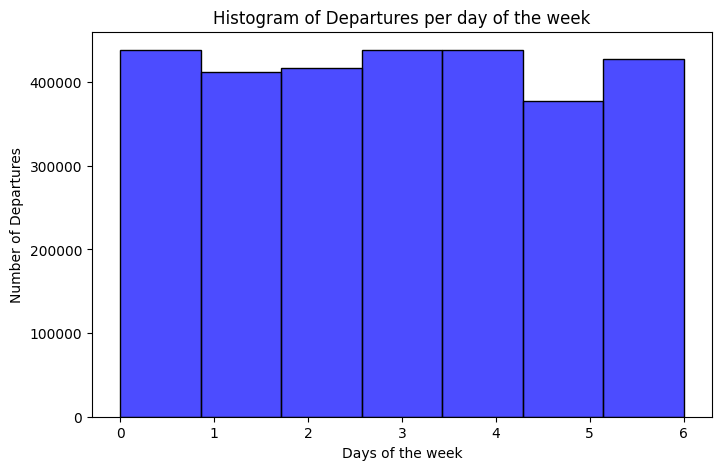

In [11]:
# Histogram of departures per day of the week
plt.figure(figsize=(8, 5))
sns.histplot(fdf["dep_datetime"].dt.dayofweek, bins=7, kde=False, color="blue", alpha=0.7)

# adding titles and labels
plt.title("Histogram of Departures per day of the week")
plt.xlabel("Days of the week")
plt.ylabel("Number of Departures")

# showing the plot
plt.show()

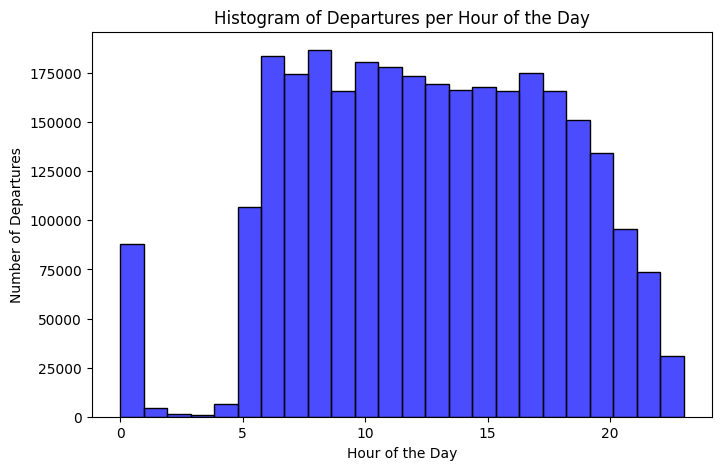

In [12]:
# Histogram of departures per hour of the day
plt.figure(figsize=(8, 5))
sns.histplot(fdf["dep_datetime"].dt.hour, bins=24, kde=False, color='blue', alpha=0.7)

# adding titles and labels
plt.title("Histogram of Departures per Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Departures")

# showing the plot
plt.show()

In [13]:
# get flights in arbitrary intervalls of departure and arrival times
def getfldep(start, end):
    return fdf.loc[ (fdf["dep_datetime"] >= start) & (fdf["dep_datetime"] < end)]

def getflarr(start, end):
    return  fdf.loc[ (fdf["arr_datetime"] >= start) & (fdf["arr_datetime"] < end)]

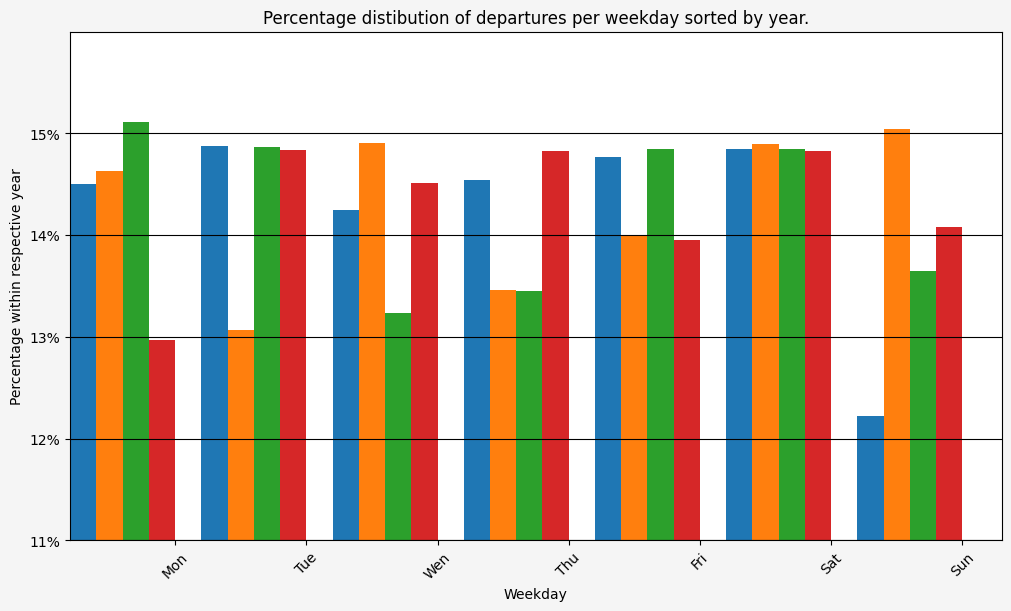

3233

In [14]:
# sorting departures by year
dep_fl19 = getfldep("2019", "2020")
dep_fl19 = dep_fl19["dep_datetime"].dt.day_name().value_counts(normalize=True, sort=False)* 100

dep_fl20 = getfldep("2020", "2021")
dep_fl20 = dep_fl20["dep_datetime"].dt.day_name().value_counts(normalize=True, sort=False)* 100

dep_fl21 = getfldep("2021", "2022")
dep_fl21 = dep_fl21["dep_datetime"].dt.day_name().value_counts(normalize=True, sort=False)* 100

dep_fl22 = getfldep("2022", "2023")
dep_fl22 = dep_fl22["dep_datetime"].dt.day_name().value_counts(normalize=True, sort=False)* 100

# plotting bar plot 
fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor="whitesmoke",
    layout="constrained",
)

xtick_label=["Mon", "Tue", "Wen", "Thu", "Fri", "Sat", "Sun"]
ytick_label=[ str(x) + "%" for x in range(11, 16)]

ax.set_title("Percentage distibution of departures per weekday sorted by year.")
ax.set_xlabel("Weekday")
ax.set_ylabel("Percentage within respective year")
ax.set_xticks([x + 0.7 for x in range(1, 8)], xtick_label, rotation=45)
ax.set_yticks([y for y in range(11, 16)], ytick_label)

ax.bar([x for x in range(1, 8)], dep_fl19, width=0.2)
ax.bar([x + 0.2 for x in range(1, 8)], dep_fl20, width=0.2)
ax.bar([x + 0.40 for x in range(1, 8)], dep_fl21, width=0.2)
ax.bar([x + 0.6 for x in range(1, 8)], dep_fl22, width=0.2)
ax.grid(True, color = "black", axis = "y")
ax.set(xlim=(0.9, 8), ylim=(11, 16))

# show the plot
plt.show()

del dep_fl19, dep_fl20, dep_fl21, dep_fl22
gc.collect()

In [15]:
# creating a GeoDataFrame from the merged data
geometry_origin = [Point(xy) for xy in zip(fdf["LONGITUDE_ORIGIN"], fdf["LATITUDE_ORIGIN"])]
geometry_dest = [Point(xy) for xy in zip(fdf["LONGITUDE_DEST"], fdf["LATITUDE_DEST"])]

# creating separate GeoDataFrames for origin and destination airports
gdf_origin = gpd.GeoDataFrame(fdf, geometry=geometry_origin)
gdf_dest = gpd.GeoDataFrame(fdf, geometry=geometry_dest)

In [16]:
# loading world data for the basemap
world_path = geodatasets.get_path("naturalearth.land")
world = gpd.read_file(world_path)

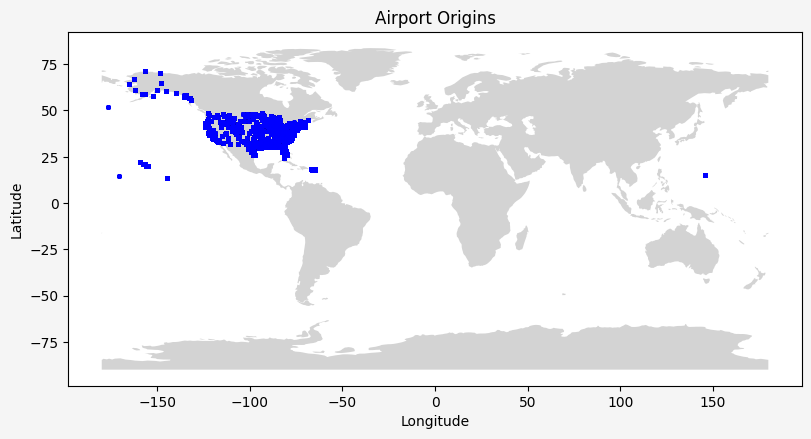

In [17]:
# creating the figure and axes with Matplotlib
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="whitesmoke", layout="constrained")

# plotting the world basemap on the axes
world.plot(ax=ax, color="lightgray")

# plotting gdf_origin  (GeoDataFrame for airport origins)
gdf_origin.plot(ax=ax, marker="o", color="blue", markersize=5)

# adding titles, labels, etc...
ax.set_title("Airport Origins")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# show the plot
plt.show()

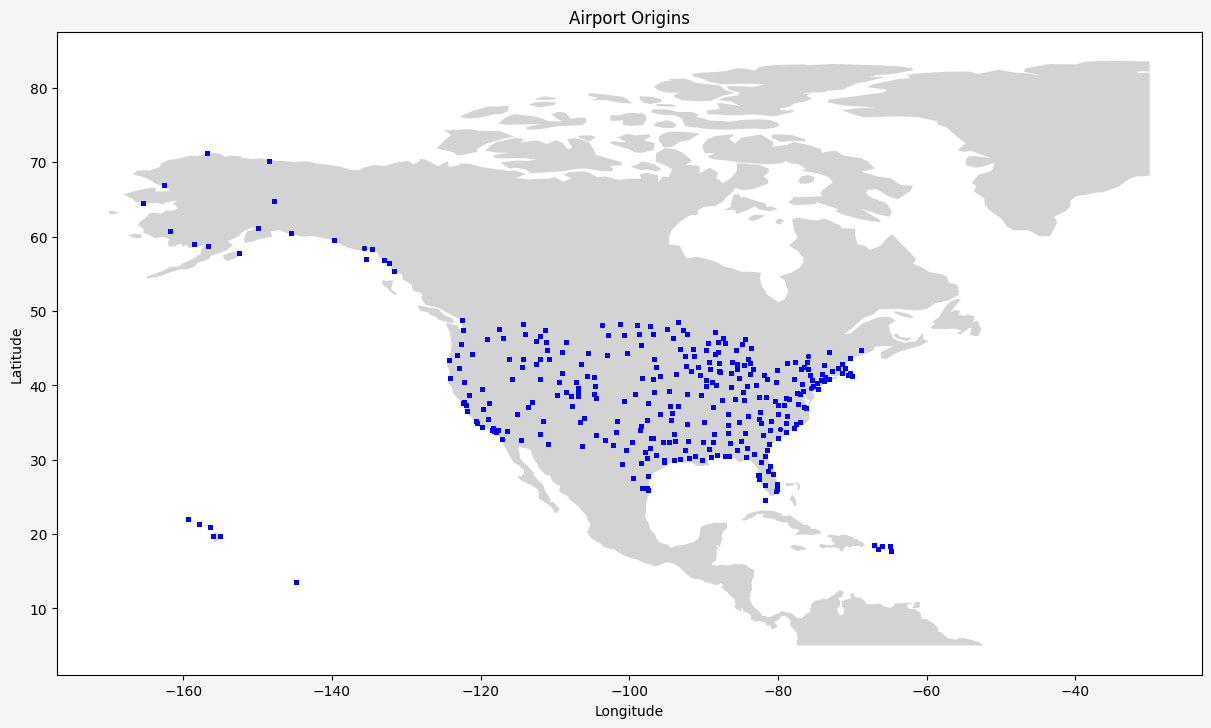

In [18]:
# define bounding box for North America (roughly)
north_america_box = box(-170, 5, -30, 85)  # (min_lon, min_lat, max_lon, max_lat)

# clipping the world land data to the bounding box of North America
north_america = world.clip(north_america_box)

# define plot
fig, ax = plt.subplots(figsize=(12, 8), facecolor="whitesmoke", layout="constrained")

# plotting northamerica
north_america.plot(ax=ax, color="lightgray")

# plotting gdf_origin on top of it  (GeoDataFrame for airport origins)
gdf_origin[
    (85 >= gdf_origin["LATITUDE_ORIGIN"]) & 
    (gdf_origin["LATITUDE_ORIGIN"] >= 5) & 
    (-30 >= gdf_origin["LONGITUDE_ORIGIN"]) &
    (gdf_origin["LONGITUDE_ORIGIN"] >= -170)
].plot(ax=ax, marker="o", color="blue", markersize=5)

ax.set_title("Airport Origins")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

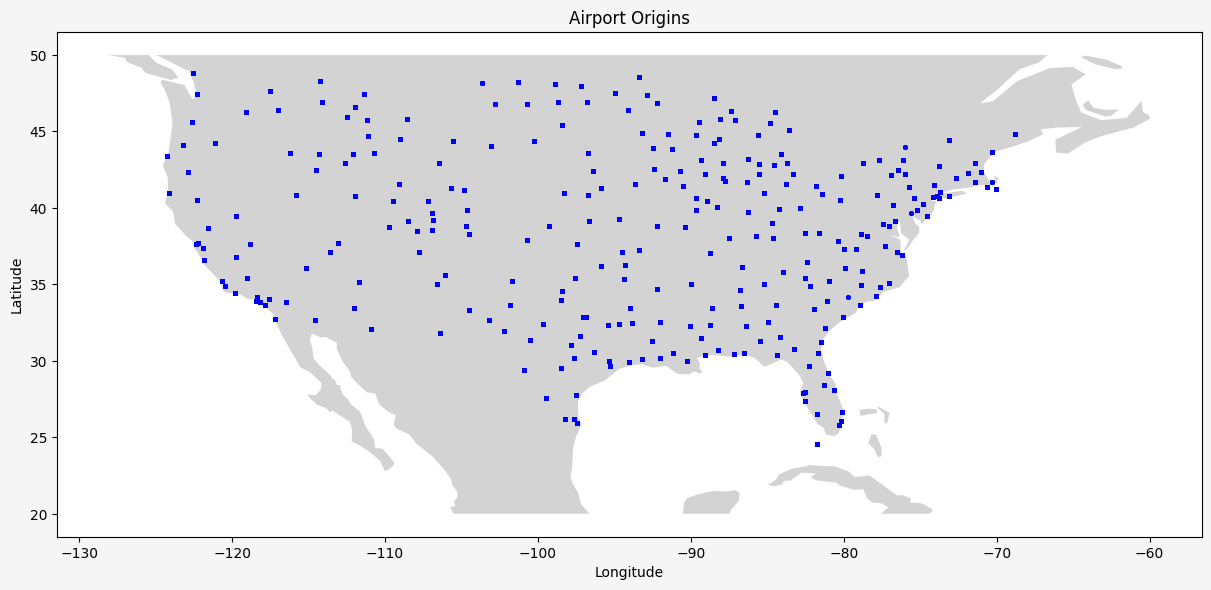

In [19]:
# USA (roughly)
north_america_box = box(-130, 20, -60, 50)  # (min_lon, min_lat, max_lon, max_lat)

# clipping the world land data to the bounding box of North America
north_america = world.clip(north_america_box)

# define plot
fig, ax = plt.subplots(figsize=(12, 8), facecolor="whitesmoke", layout="constrained")

# plotting northamerica
north_america.plot(ax=ax, color="lightgray")

# plotting gdf_origin on top of it  (GeoDataFrame for airport origins)
gdf_origin[
    (50 >= gdf_origin["LATITUDE_ORIGIN"]) & 
    (gdf_origin["LATITUDE_ORIGIN"] >= 20) & 
    (-60 >= gdf_origin["LONGITUDE_ORIGIN"]) &
    (gdf_origin["LONGITUDE_ORIGIN"] >= -130)
].plot(ax=ax, marker="o", color="blue", markersize=5)

ax.set_title("Airport Origins")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [20]:
del world, north_america
del gdf_origin
del gdf_dest
del geometry_origin
del geometry_dest

gc.collect()

11091

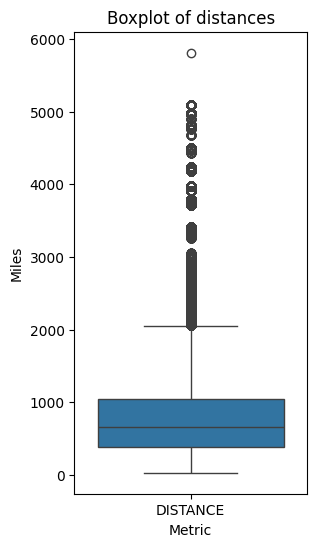

131

In [21]:
# prepairing data for boxplots to take a view about outliers when it comes to distances
melted_data = fdf.melt(value_vars=["DISTANCE"], var_name="Metric", value_name="Miles")

# plotting
plt.figure(figsize=(3,6))
sns.boxplot(x="Metric", y="Miles", data=melted_data, legend=False)
plt.title("Boxplot of distances")

# showing the plot
plt.show()

del melted_data
gc.collect()

In [22]:
# scoping out origin_cities with the highest count of flights
print(fdf["ORIGIN_CITY"].value_counts().head(20), "\n")

# scoping out origin_airports with the highest count of flights
print(fdf["IATA_ORIGIN"].value_counts().head(20))

ORIGIN_CITY
Chicago, IL              156023
Atlanta, GA              152253
Dallas/Fort Worth, TX    129446
Denver, CO               117390
New York, NY             112989
Charlotte, NC             93352
Houston, TX               86346
Los Angeles, CA           85304
Washington, DC            78286
Phoenix, AZ               74411
Las Vegas, NV             72993
Seattle, WA               70050
Orlando, FL               63712
Detroit, MI               62279
Minneapolis, MN           59838
San Francisco, CA         59176
Boston, MA                55387
Newark, NJ                52946
Salt Lake City, UT        52027
Philadelphia, PA          42600
Name: count, dtype: int64 

IATA_ORIGIN
ATL    152253
DFW    129446
ORD    121019
DEN    117390
CLT     93352
LAX     85304
PHX     74411
LAS     72993
SEA     70050
MCO     63712
LGA     62523
DTW     62279
IAH     62192
MSP     59838
SFO     59176
BOS     55387
DCA     53076
EWR     52946
SLC     52027
JFK     50466
Name: count, dtype: int64


In [23]:
# scoping out the top ten most popular routes (cities)
route_counts = fdf.groupby(["ORIGIN_CITY", "DEST_CITY"], observed=True).size().reset_index(name="flight_count")
most_pop_routes = route_counts.sort_values(by="flight_count", ascending=False)
most_pop_routes.head(10)

,ORIGIN_CITY,DEST_CITY,flight_count
4086,"New York, NY","Chicago, IL",6775
1192,"Chicago, IL","New York, NY",6572
4076,"New York, NY","Boston, MA",5618
697,"Boston, MA","New York, NY",5591
5452,"San Francisco, CA","Los Angeles, CA",5358
3370,"Los Angeles, CA","San Francisco, CA",5212
301,"Atlanta, GA","New York, NY",4882
4068,"New York, NY","Atlanta, GA",4872
2893,"Kahului, HI","Honolulu, HI",4656
3332,"Los Angeles, CA","Las Vegas, NV",4627


In [24]:
# scoping out the top ten most popular routes (IATA)
route_counts = fdf.groupby(["IATA_ORIGIN", "IATA_DEST"], observed=True).size().reset_index(name="flight_count")
most_pop_routes = route_counts.sort_values(by="flight_count", ascending=False)
most_pop_routes.head(10)

,IATA_ORIGIN,IATA_DEST,flight_count
6198,SFO,LAX,5358
3616,LAX,SFO,5212
3726,LGA,ORD,4735
4708,OGG,HNL,4656
4913,ORD,LGA,4634
3572,LAX,LAS,4627
2730,HNL,OGG,4554
3450,LAS,LAX,4550
3570,LAX,JFK,4403
3308,JFK,LAX,4305


In [25]:
# filtering out only flights that are not cancelled
non_cancelled_flights = fdf[~fdf["CANCELLED"]]

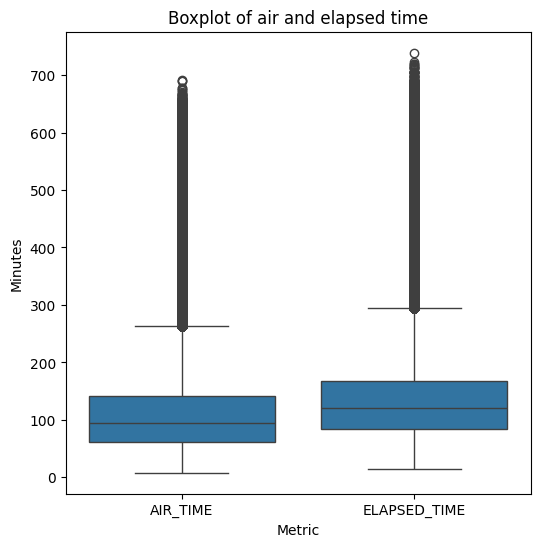

2985

In [26]:
# prepairing data for boxplots to take a view about outliers when it comes to flightdurations
melted_data = non_cancelled_flights.melt(value_vars=["AIR_TIME", "ELAPSED_TIME"], 
                                         var_name="Metric", value_name="Minutes")

# setting up the boxplots
plt.figure(figsize=(6,6))
sns.boxplot(x="Metric", y="Minutes", data=melted_data, legend=False)
plt.title("Boxplot of air and elapsed time")

# showing plot 
plt.show()

del melted_data 
gc.collect()

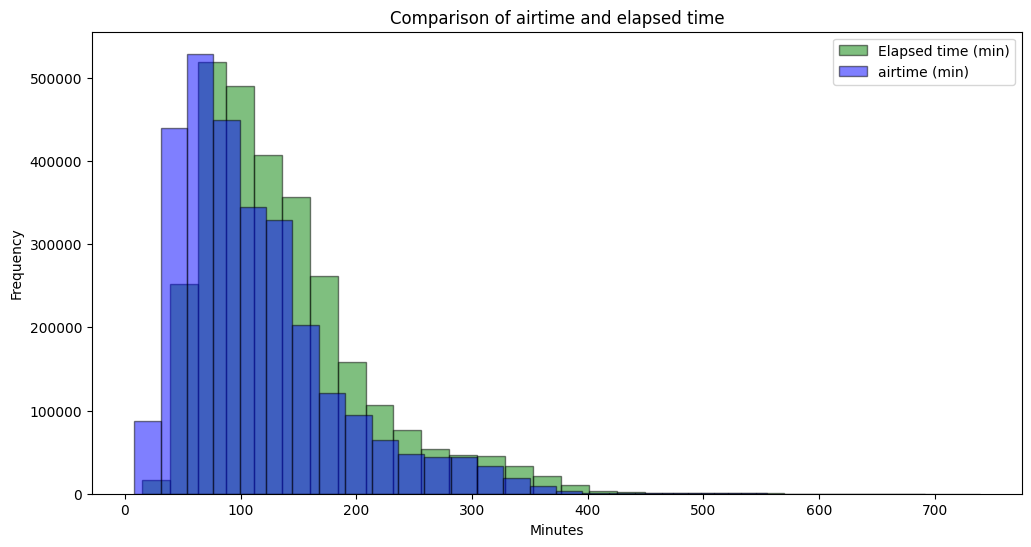

In [27]:
# overlapping Histograms to compare airtime vs. elapsed time
plt.figure(figsize=(12, 6))

plt.hist(non_cancelled_flights["ELAPSED_TIME"], bins=30, alpha=0.5, label="Elapsed time (min)", color="green", edgecolor="black")
plt.hist(non_cancelled_flights["AIR_TIME"], bins=30, alpha=0.5, label="airtime (min)", color="blue", edgecolor="black")

plt.title("Comparison of airtime and elapsed time")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.legend(loc="upper right")

plt.show()

In [28]:
# calculating haversinedistance
fdf["haversine_distance"] = coriolis_functions.haversine(
    fdf["LATITUDE_ORIGIN"],
    fdf["LONGITUDE_ORIGIN"],
    fdf["LATITUDE_DEST"], 
    fdf["LONGITUDE_DEST"]
)

In [29]:
# printing number of before rows 
print("number of rows before cleaning: ", rows_before_cleaning := len(fdf))

# clean up for model
fdf.dropna(subset=["total_drift_distance", "haversine_distance"], inplace=True)

# printing number of rows after cleaning
print("number of rows after cleaning: ", len(fdf))
print("number of rows lost due cleaning: ", rows_before_cleaning - len(fdf))

number of rows before cleaning:  2948087
number of rows after cleaning:  2730145
number of rows lost due cleaning:  217942


In [30]:
# defining a function for DBSCAN and plotting
def db_scanner(data, fdf, epsilon, minimum_samples):
    # configuring DBSCAN parameters
    dbscan = DBSCAN(eps=epsilon, min_samples=minimum_samples)
    clusters = dbscan.fit_predict(data)
    
    # adding cluster labels to the dataframe
    fdf["cluster"] = clusters
    
    # creating a figure with 2 subplots, one above the other
    fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
    
    # first plot: including noise
    sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf, hue="cluster", palette="viridis", alpha=0.5, ax=axes[0])
    axes[0].set_title("DBSCAN Clustering (Including Noise)")
    axes[0].set_xlabel("Haversine Distance")
    axes[0].set_ylabel("Total Drift Distance")
    axes[0].legend(loc="upper left", title="Cluster")
    
    # second plot: excluding noise
    sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf[fdf["cluster"] != -1], hue="cluster", palette="viridis", alpha=0.5, ax=axes[1])
    axes[1].set_title("DBSCAN Clustering (Excluding Noise)")
    axes[1].set_xlabel("Haversine Distance")
    axes[1].set_ylabel("Total Drift Distance")
    axes[1].legend(loc="upper left", title="Cluster")
    
    # adjust layout
    plt.tight_layout()
    plt.show()
    
    # Print information about noise
    print(f"Flights not considered 'noise': {len(fdf[fdf['cluster'] != -1])}")
    print(f"Flights considered 'noise': {len(fdf[fdf['cluster'] == -1])}")
    
    # cleaning up large variables to free up memory
    del clusters
    gc.collect()

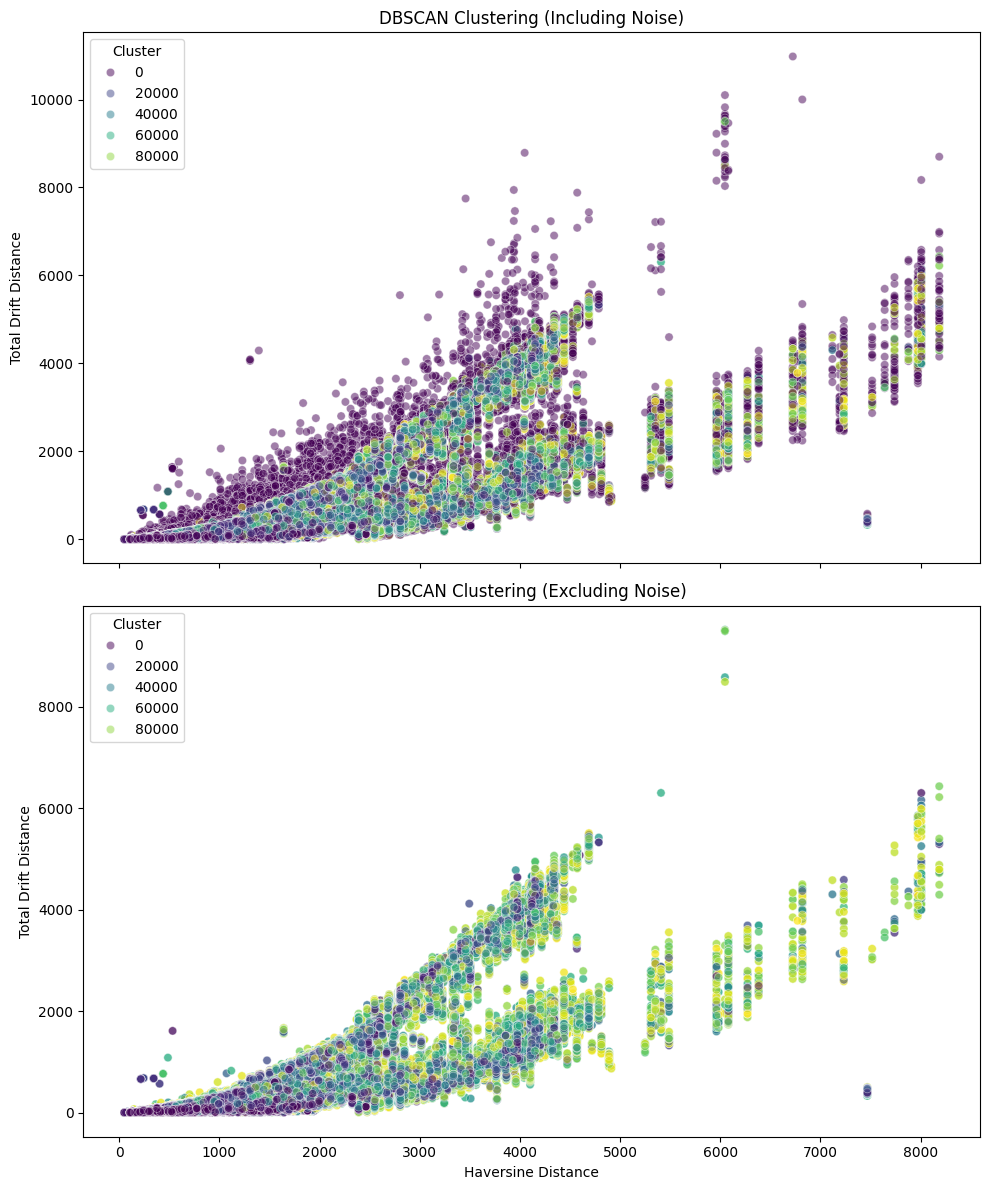

Flights not considered 'noise': 2689283
Flights considered 'noise': 40862


7923

In [31]:
# extracting data into 2D numpy array
data = fdf[["haversine_distance", "total_drift_distance"]].to_numpy()

db_scanner(data, fdf, 0.99, 2)

del data
gc.collect()

In [32]:
# dropping noise 
# Print number of rows before cleaning
print("Number of rows before cleaning: ", rows_before_cleaning := len(fdf))

# Drop outliers (rows labeled as -1) inplace
fdf.drop(fdf[fdf["cluster"] == -1].index, inplace=True)

# Print number of rows after cleaning
print("Number of rows after cleaning: ", len(fdf))
print("Number of rows lost due to cleaning: ", rows_before_cleaning - len(fdf))

Number of rows before cleaning:  2730145
Number of rows after cleaning:  2689283
Number of rows lost due to cleaning:  40862


In [33]:
# cleaning a temporary dataframe 
print("\nNumber of rows before further cleaning: ", rows_before_cleaning := len(fdf))

fdf_cleaned = fdf.dropna(subset=["DEP_DELAY", "ARR_DELAY"])

print("Number of rows after further cleaning: ", len(fdf_cleaned))
print("Number of rows lost due cleaning: ", rows_before_cleaning - len(fdf_cleaned))


Number of rows before further cleaning:  2689283
Number of rows after further cleaning:  2688224
Number of rows lost due cleaning:  1059


Slope by scikit-learn (m):  1.0072645445585653
Intercept by scikit-learn (b):  -6.034482650553879
R² by scikit-learn:  0.9285975497563297


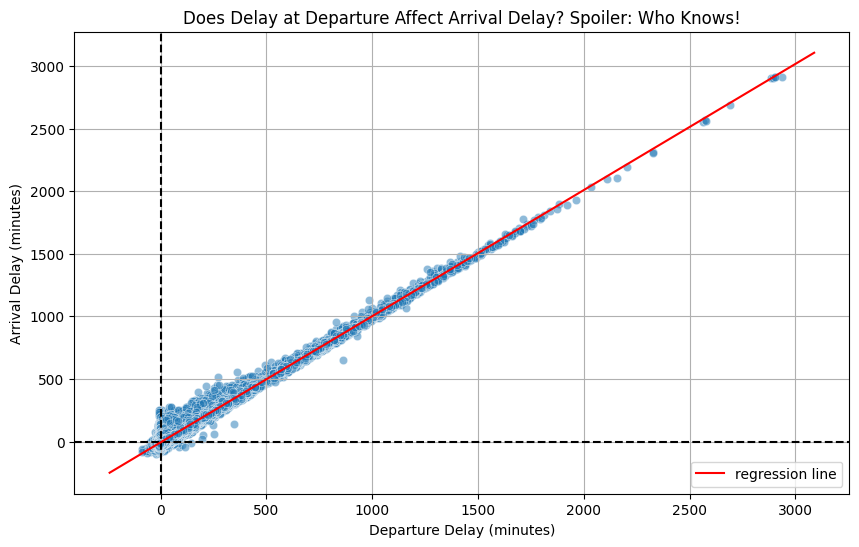

156

In [34]:
# linear regression using scikit-learn
X = fdf_cleaned["DEP_DELAY"].values.reshape(-1, 1)
Y = fdf_cleaned["ARR_DELAY"].values

model = LinearRegression()
model.fit(X, Y)

m = model.coef_[0]
b = model.intercept_
r_squared = model.score(X, Y)

print("Slope by scikit-learn (m): ", m)
print("Intercept by scikit-learn (b): ", b)
print("R² by scikit-learn: ", r_squared)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="DEP_DELAY", y="ARR_DELAY", data=fdf_cleaned, alpha=0.5)

plt.title("Does Delay at Departure Affect Arrival Delay? Spoiler: Who Knows!")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.axhline(0, color="0", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="0", linestyle="--")  # Reference line for y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = b + m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.legend(loc="lower right")
plt.show()

del fdf_cleaned, X, Y, x_vals, y_vals
gc.collect()

In [35]:
X = fdf[["haversine_distance", "total_drift_distance"]].values

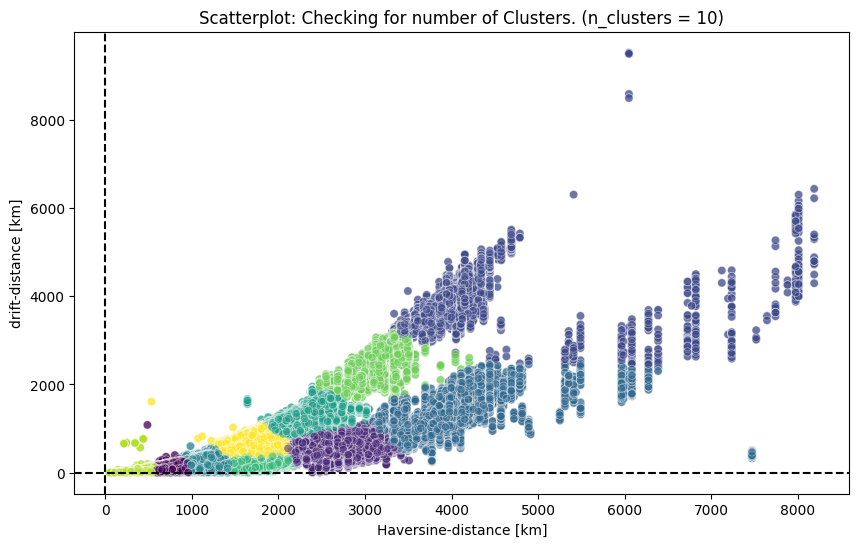

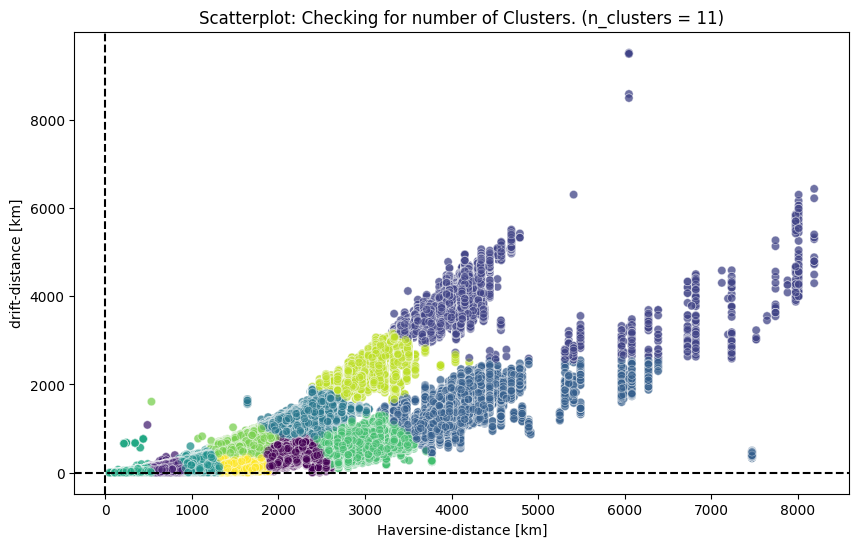

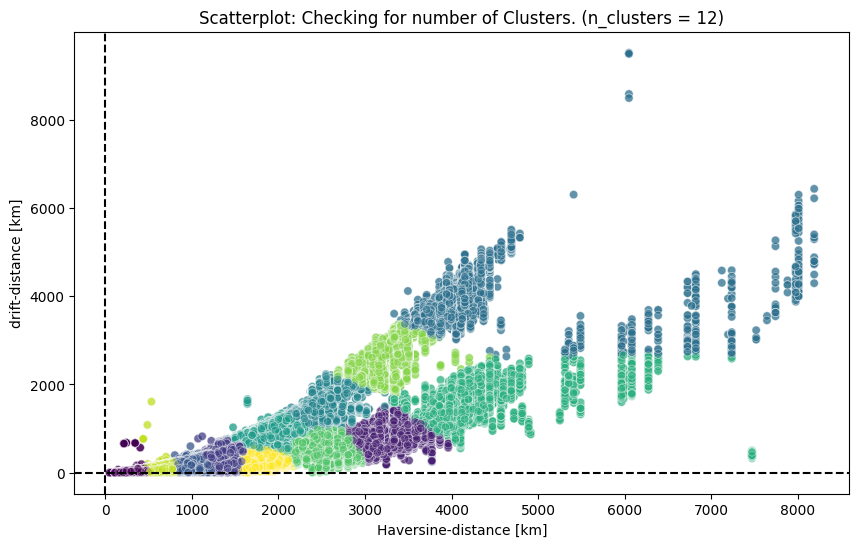

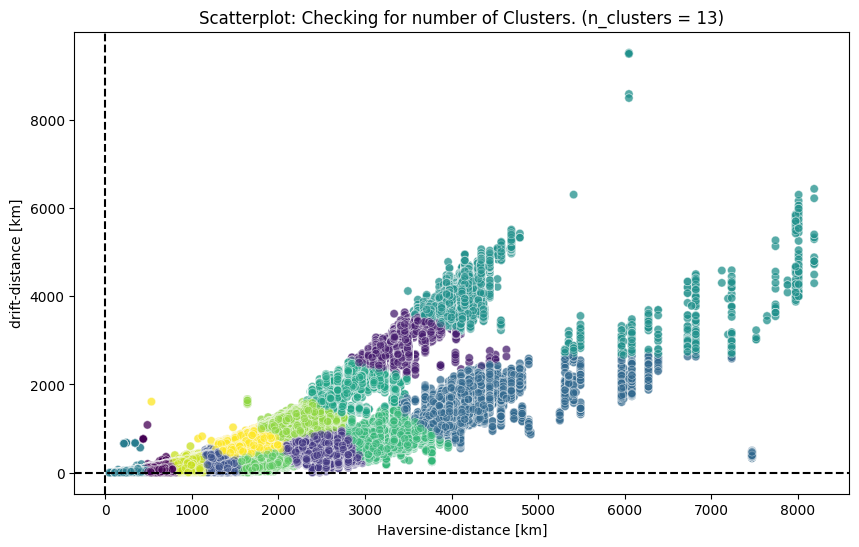

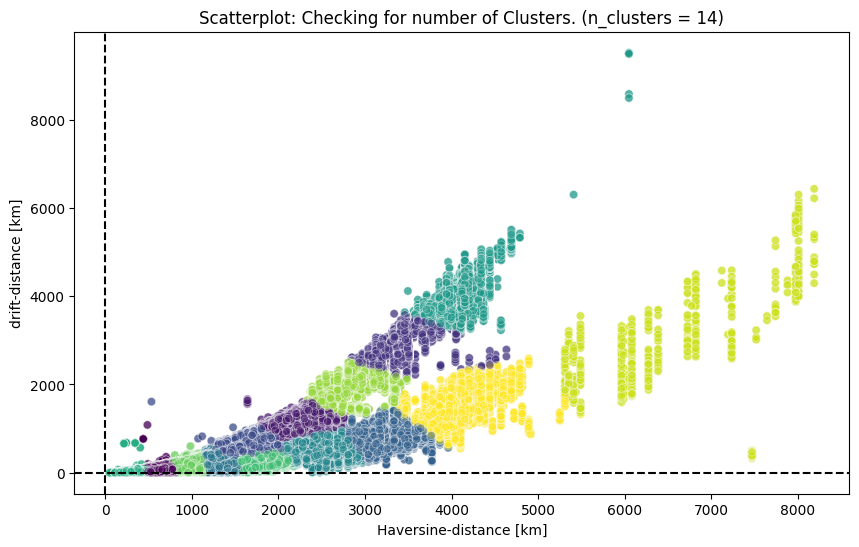

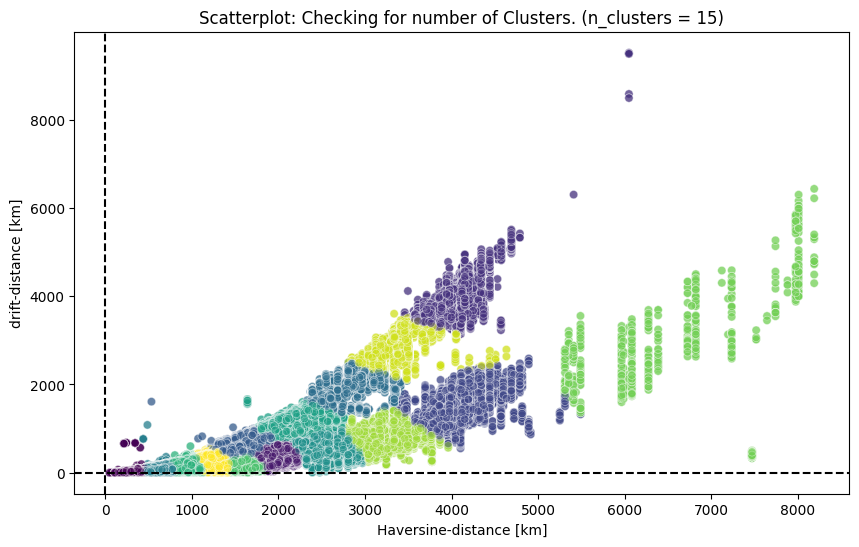

In [36]:
for i in range(10, 16):
    # applying kmeans
    kmeans = KMeans(n_clusters=i, n_init=20, random_state=42)  # adjusting number of clusters
    kmeans.fit(X)
    fdf["cluster"] = kmeans.labels_
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="haversine_distance", y="total_drift_distance", c=fdf["cluster"], cmap="viridis", data=fdf, alpha=0.5)
    
    plt.title(f"Scatterplot: Checking for number of Clusters. (n_clusters = {i})")
    plt.xlabel("Haversine-distance [km]")
    plt.ylabel("drift-distance [km]")
    
    plt.axhline(0, color="0", linestyle="--")  # Reference line for x-axis
    plt.axvline(0, color="0", linestyle="--")  # Reference line for y-axis
    
    plt.show()

In [37]:
# linear regression using scikit-learn
X = fdf["haversine_distance"].values.reshape(-1, 1)
Y = fdf["total_drift_distance"].values

model = LinearRegression()
model.fit(X, Y)

print("Slope by scikit-learn (m): ", sk_m := model.coef_[0])
print("Intercept by scikit-learn (b): ", sk_b := model.intercept_)
print("R² by scikit-learn: ", r_squared := model.score(X, Y))

# plotting regression
# plt.plot(x_vals, y_vals, color="red", label="regression line")

Slope by scikit-learn (m):  0.5361271441505658
Intercept by scikit-learn (b):  -350.75227336967896
R² by scikit-learn:  0.5847649476543273


In [38]:
# let's try a scond order polynomial and calculate R² along the way
coefs = np.polyfit(fdf["haversine_distance"], fdf["total_drift_distance"], 2)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf["haversine_distance"])

ss_res = np.sum((fdf["total_drift_distance"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf["total_drift_distance"] - np.mean(fdf["total_drift_distance"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)
                
print("Coefficients for polynomial: ", coefs)
print("R² of the polynomial: ", poly_r_squared)

# setup polynomial for plot
polya_x_values = np.linspace(fdf["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
polya_y_values = np.polyval(coefs, polya_x_values)

# plotting polynomial
# plt.plot(poly_x_vals, poly_y_vals, color="red", label="polynomial fit")

Coefficients for polynomial:  [ 1.16362169e-04  9.15644035e-02 -6.73634809e+01]
R² of the polynomial:  0.6381130714183274


In [39]:
# let's try a fifth order polynomial and calculate R² along the way
coefs = np.polyfit(fdf["haversine_distance"], fdf["total_drift_distance"], 5)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf["haversine_distance"])

ss_res = np.sum((fdf["total_drift_distance"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf["total_drift_distance"] - np.mean(fdf["total_drift_distance"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)

for i, coefficient in enumerate(coefs):
    print(f"{i}. coef for polynomial: ", coefficient)
print("R² of the polynomial: ", poly_r_squared)

# setup polynomial for plot
polyb_x_values = np.linspace(fdf["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
polyb_y_values = np.polyval(coefs, polyb_x_values)


0. coef for polynomial:  4.185956384209723e-15
1. coef for polynomial:  -7.016479358888208e-11
2. coef for polynomial:  3.641356361485188e-07
3. coef for polynomial:  -0.0005687900944411575
4. coef for polynomial:  0.47842752988522197
5. coef for polynomial:  -86.63074960322001
R² of the polynomial:  0.670181926138093


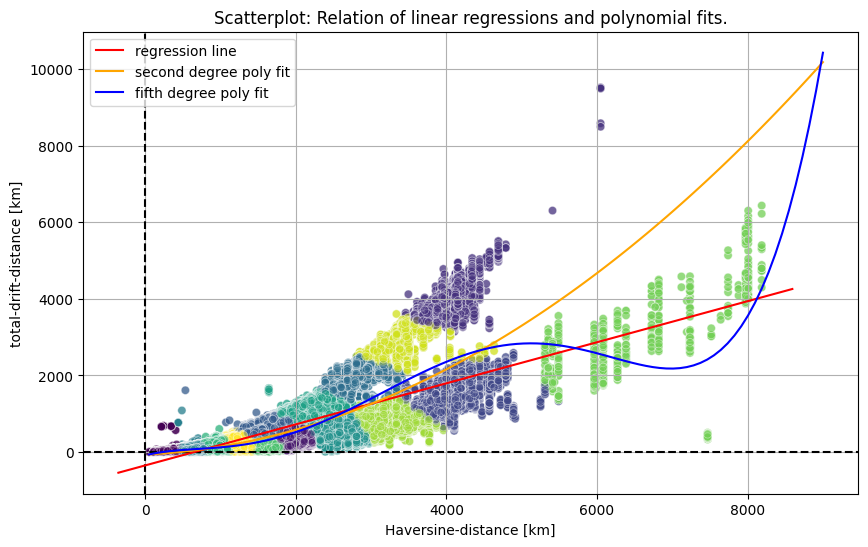

In [40]:
# let's compare
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", c=fdf["cluster"], cmap="viridis", data=fdf, alpha=0.5)

plt.title("Scatterplot: Relation of linear regressions and polynomial fits.")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="0", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="0", linestyle="--")  # Reference line for y-axis

# adding in linear regression  
x_values = np.array(plt.gca().get_xlim())
y_values = sk_b + sk_m * x_values

# plotting linear regression
plt.plot(x_values, y_values, color="red", label="regression line")

# adding polynomials for plot
plt.plot(polya_x_values, polya_y_values, color="orange", label="second degree poly fit")
plt.plot(polyb_x_values, polyb_y_values, color="blue", label="fifth degree poly fit")

plt.grid(True)
plt.legend(loc="upper left")
plt.show()

In [41]:
# division of drift through distance gives percentage
fdf.loc[:, "drift_factor"] = fdf["total_drift_distance"] / fdf["haversine_distance"].replace(0, pd.NA)

In [42]:
X = fdf[["haversine_distance", "drift_factor"]].values

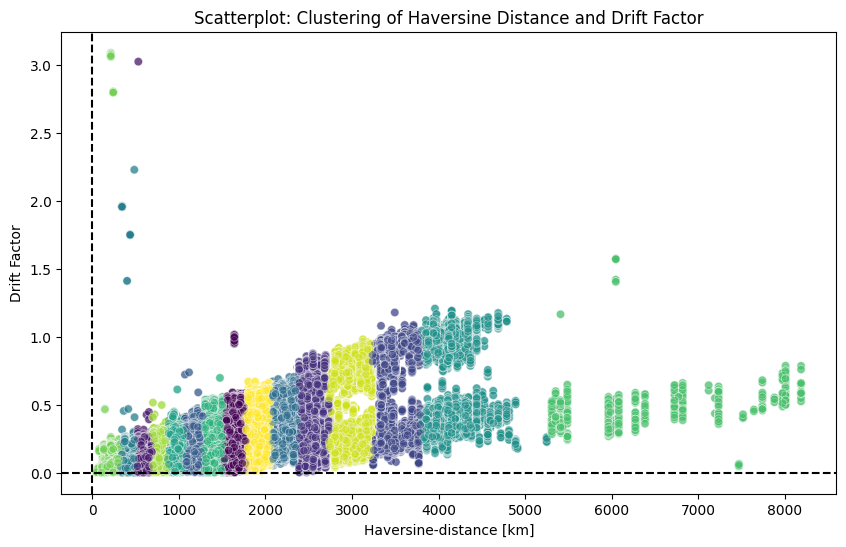

In [43]:
# applying kmeans
kmeans = KMeans(n_clusters=15)  # adjusting number of clusters
kmeans.fit(X)
fdf["cluster_df"] = kmeans.labels_

plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="drift_factor", c=fdf["cluster_df"], cmap="viridis", data=fdf, alpha=0.5)

plt.title("Scatterplot: Clustering of Haversine Distance and Drift Factor")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("Drift Factor")

plt.axhline(0, color="0", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="0", linestyle="--")  # Reference line for y-axis

plt.show()

In [44]:
# linear regression using scikit-learn
X = fdf["haversine_distance"].values.reshape(-1, 1)
Y = fdf["drift_factor"].values

model = LinearRegression()
model.fit(X, Y)

print("Slope by scikit-learn (m): ", scikit_m := model.coef_[0])
print("Intercept by scikit-learn (b): ", scikit_b := model.intercept_)
print("R² by scikit-learn: ", r_squared := model.score(X, Y))

# plotting regression
# plt.plot(x_vals, y_vals, color="red", label="regression line")

Slope by scikit-learn (m):  0.00013865173448335185
Intercept by scikit-learn (b):  -0.0039053837443795147
R² by scikit-learn:  0.44650386566992595


In [45]:
# let's try a scond order polynomial and calculate R² along the way
coefs = np.polyfit(fdf["haversine_distance"], fdf["drift_factor"], 2)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf["haversine_distance"])

ss_res = np.sum((fdf["drift_factor"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf["drift_factor"] - np.mean(fdf["drift_factor"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)
                
print("Coefficients for polynomial: ", coefs)
print("R² of the polynomial: ", poly_r_squared)

# setup polynomial for plot
polya_x_vals = np.linspace(fdf["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
polya_y_vals = np.polyval(coefs, polya_x_vals)

# plotting polynomial
# plt.plot(poly_x_vals, poly_y_vals, color="red", label="polynomial fit")

Coefficients for polynomial:  [5.32482775e-09 1.18308181e-04 9.06271853e-03]
R² of the polynomial:  0.447779233718435


In [46]:
# let's try a fifth order polynomial and calculate R² along the way
coefs = np.polyfit(fdf["haversine_distance"], fdf["drift_factor"], 5)

# and calculate R²
poly = np.poly1d(coefs)
y_predictions = poly(fdf["haversine_distance"])

ss_res = np.sum((fdf["drift_factor"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf["drift_factor"] - np.mean(fdf["drift_factor"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)

for i, coefficient in enumerate(coefs):
    print(f"{i}. coef for polynomial: ", coefficient)
print("R² of the polynomial: ", poly_r_squared)

# setup polynomial for plot
polyb_x_vals = np.linspace(fdf["haversine_distance"].min(), 9000, 100) # 9000 is to cut off plot
polyb_y_vals = np.polyval(coefs, polyb_x_vals)


0. coef for polynomial:  1.0341174120781931e-18
1. coef for polynomial:  -1.6074561492303293e-14
2. coef for polynomial:  7.514262332716832e-11
3. coef for polynomial:  -1.1175306279775957e-07
4. coef for polynomial:  0.00015282977488949743
5. coef for polynomial:  0.022612430686289778
R² of the polynomial:  0.4661880636431067


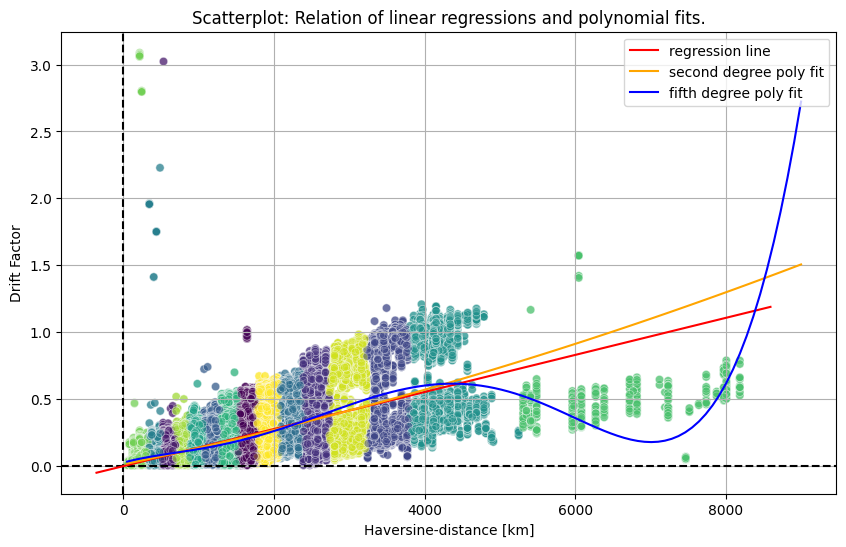

In [47]:
# let's compare
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="drift_factor", c=fdf["cluster_df"], cmap="viridis", data=fdf, alpha=0.5)

plt.title("Scatterplot: Relation of linear regressions and polynomial fits.")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("Drift Factor")

plt.axhline(0, color="0", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="0", linestyle="--")  # Reference line for y-axis

# adding in linear regression  
x_vals = np.array(plt.gca().get_xlim())
y_vals = scikit_b + scikit_m * x_vals

# plotting linear regression
plt.plot(x_vals, y_vals, color="red", label="regression line")

# adding polynomials for plot
plt.plot(polya_x_vals, polya_y_vals, color="orange", label="second degree poly fit")
plt.plot(polyb_x_vals, polyb_y_vals, color="blue", label="fifth degree poly fit")

plt.grid(True)
plt.legend(loc="upper right")
plt.show()

In [48]:
# changing colors

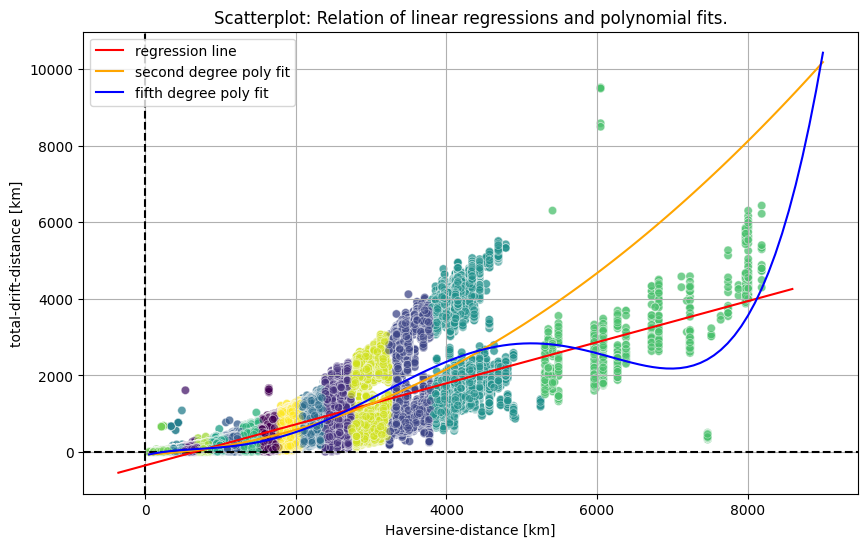

In [49]:
# plotting haversine distance and drift distance 

plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", c=fdf["cluster_df"], cmap="viridis", data=fdf, alpha=0.5)

plt.title("Scatterplot: Relation of linear regressions and polynomial fits.")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("total-drift-distance [km]")

plt.axhline(0, color="0", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="0", linestyle="--")  # Reference line for y-axis

# adding in linear regression  
x_values = np.array(plt.gca().get_xlim())
y_values = sk_b + sk_m * x_values

# plotting linear regression
plt.plot(x_values, y_values, color="red", label="regression line")

# adding polynomials for plot
plt.plot(polya_x_values, polya_y_values, color="orange", label="second degree poly fit")
plt.plot(polyb_x_values, polyb_y_values, color="blue", label="fifth degree poly fit")

plt.grid(True)
plt.legend(loc="upper left")
plt.show()

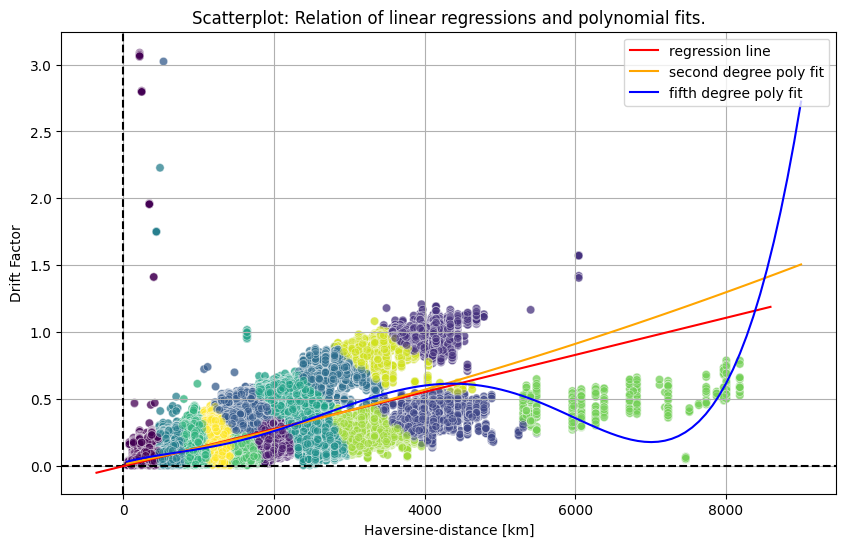

In [50]:
# plotting haversine distance and drift factor 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="drift_factor", c=fdf["cluster"], cmap="viridis", data=fdf, alpha=0.5)

plt.title("Scatterplot: Relation of linear regressions and polynomial fits.")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("Drift Factor")

plt.axhline(0, color="0", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="0", linestyle="--")  # Reference line for y-axis

# adding in linear regression  
x_vals = np.array(plt.gca().get_xlim())
y_vals = scikit_b + scikit_m * x_vals

# plotting linear regression
plt.plot(x_vals, y_vals, color="red", label="regression line")

# adding polynomials for plot
plt.plot(polya_x_vals, polya_y_vals, color="orange", label="second degree poly fit")
plt.plot(polyb_x_vals, polyb_y_vals, color="blue", label="fifth degree poly fit")

plt.grid(True)
plt.legend(loc="upper right")
plt.show()